In [1]:
import os
import torch

# Make only GPU 0 visible
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# After setting environment variable, import torch and select device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Available GPUs:", torch.cuda.device_count())
    print("Current device ID:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA not available, using CPU.")


Using device: cuda:0
GPU Name: NVIDIA A100-PCIE-40GB
Available GPUs: 1
Current device ID: 0
Device name: NVIDIA A100-PCIE-40GB


In [2]:
!pip install matplotlib

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("ProtBERT_embeddings_training.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Target
0,-0.034950,-0.140915,0.018164,0.113025,-0.039345,-0.011524,-0.031041,-0.040668,-0.026480,0.009581,...,-0.096869,-0.095261,-0.081897,0.166652,0.043509,0.113799,0.088787,-0.109871,0.078579,1
1,0.024519,-0.042383,0.091386,0.097758,-0.117725,-0.098035,-0.024405,0.007786,0.101808,-0.096753,...,-0.085767,-0.151462,-0.069614,0.105204,0.038671,0.162585,-0.104979,-0.074768,0.039123,1
2,0.041404,-0.109655,0.031160,0.089205,-0.063266,-0.066166,-0.119548,-0.019737,0.097363,-0.142750,...,-0.096535,-0.191988,-0.016793,0.039914,-0.096920,0.054166,-0.025659,-0.008478,0.046423,1
3,0.021859,-0.048087,0.016332,0.072064,-0.050601,-0.003789,0.019974,0.023903,0.016436,0.018024,...,0.036430,0.022632,-0.037588,0.137869,-0.015566,0.040146,-0.017984,-0.026280,0.072870,1
4,0.011861,-0.050165,-0.002656,0.091067,-0.041076,0.016872,-0.009605,-0.004270,-0.026167,0.049497,...,-0.005988,-0.006798,0.017307,0.091325,-0.030920,0.085731,-0.010519,-0.012574,0.095992,1


In [5]:
df.shape

(707, 1025)

In [6]:
X = df.drop("Target",axis=1)
y = df["Target"]
X,y

(            0         1         2         3         4         5         6  \
 0   -0.034950 -0.140915  0.018164  0.113025 -0.039345 -0.011524 -0.031041   
 1    0.024519 -0.042383  0.091386  0.097758 -0.117725 -0.098035 -0.024405   
 2    0.041404 -0.109655  0.031160  0.089205 -0.063266 -0.066166 -0.119548   
 3    0.021859 -0.048087  0.016332  0.072064 -0.050601 -0.003789  0.019974   
 4    0.011861 -0.050165 -0.002656  0.091067 -0.041076  0.016872 -0.009605   
 ..        ...       ...       ...       ...       ...       ...       ...   
 702 -0.012843 -0.014550  0.052084 -0.005340 -0.009069 -0.072230  0.013987   
 703  0.001808 -0.034821  0.032677 -0.005266 -0.001301 -0.040320 -0.013136   
 704  0.054622 -0.003960  0.018695  0.015868 -0.030579  0.009206 -0.038183   
 705  0.027437 -0.013821  0.030450  0.012585 -0.029815 -0.053558  0.002639   
 706 -0.005574  0.005952  0.023183  0.020458  0.026587 -0.017876 -0.026454   
 
             7         8         9  ...      1014      1015   

In [7]:
import numpy as np
X_train = np.array(X)
y_train = np.array(y)
y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [9]:
X_train.shape

(707, 1024)

In [14]:
df_test = pd.read_csv("ProtBERT_embeddings_testing.csv")

X_test = np.array(df_test.drop("Target",axis=1))
y_test = np.array( df_test["Target"])

In [15]:
X_test,y_test

(array([[ 0.04362527,  0.03401236, -0.07515985, ...,  0.04331249,
          0.05308199, -0.01135546],
        [ 0.01167388, -0.0614799 , -0.03438734, ...,  0.00367419,
         -0.04140286,  0.09812184],
        [ 0.04564324, -0.06648494,  0.12555288, ..., -0.0545459 ,
          0.04333299, -0.04677253],
        ...,
        [-0.04104244, -0.01214447,  0.0062315 , ..., -0.05301742,
         -0.058989  ,  0.01164532],
        [ 0.02224705, -0.02382697,  0.02322389, ..., -0.01663663,
         -0.01748381, -0.01411216],
        [ 0.02637375,  0.00018456,  0.02393532, ..., -0.02493501,
         -0.02796087,  0.0366505 ]], shape=(178, 1024)),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,


--- Running MLP ---
Starting hyperparameter tuning...
Best hyperparameters:
{'activation': 'relu', 'batch_norm': True, 'batch_size': 16, 'dropout': 0.1, 'epochs': 15, 'hidden_dim': 128, 'lr': 0.001, 'num_layers': 2, 'optimizer': 'adam', 'weight_decay': 0}
Optimal threshold (Youden's J): 0.6552

--- Evaluation Metrics ---
Accuracy: 0.9438
Specificity: 0.9744
Precision: 0.9474
Recall: 0.8852
F1 Score: 0.9153
MCC: 0.8744
AUC: 0.9639
Brier Score: 0.0570


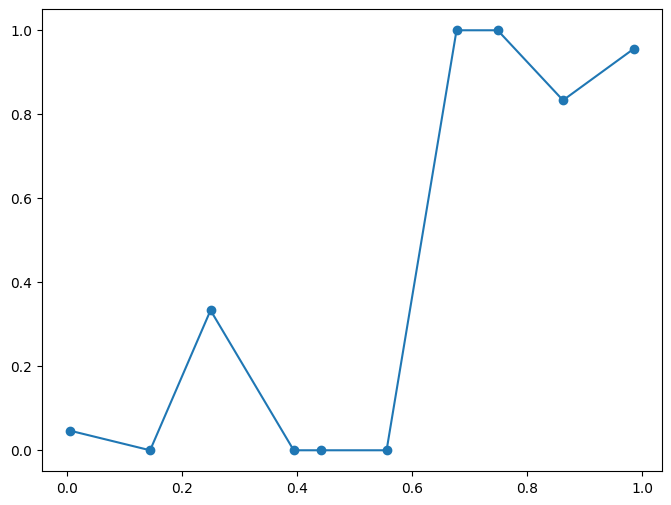

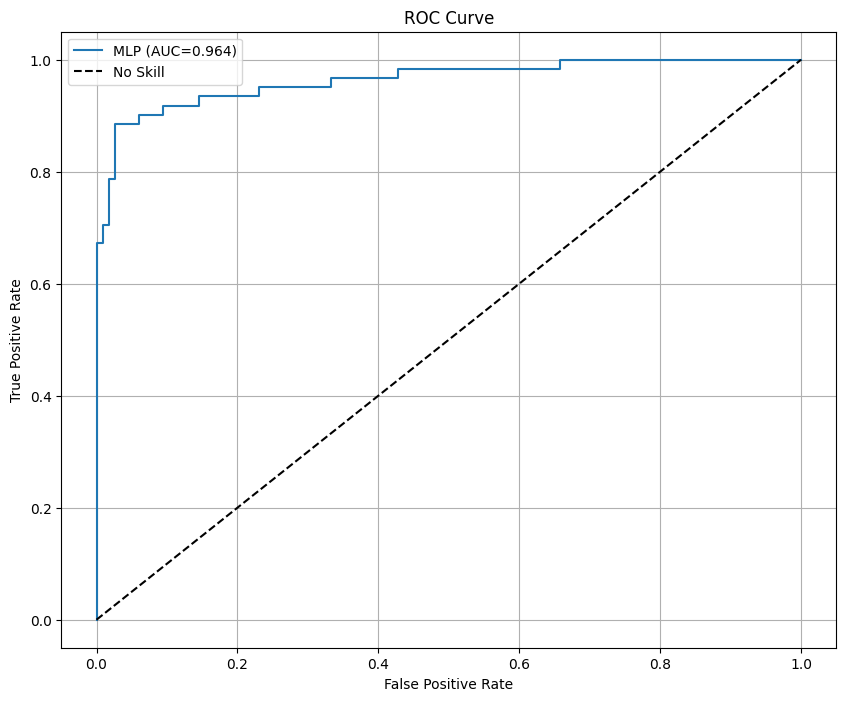

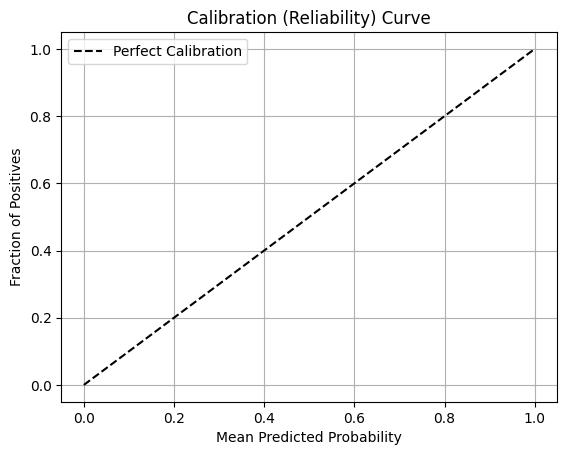

In [19]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    matthews_corrcoef, roc_auc_score, roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt


class TorchMLPClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self,
                 input_dim,
                 num_classes=2,
                 hidden_dim=128,
                 num_layers=2,
                 activation='relu',
                 dropout=0.1,
                 batch_norm=False,
                 optimizer='adam',
                 lr=1e-3,
                 weight_decay=0,
                 batch_size=32,
                 epochs=30,
                 device=None):

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.activation = activation
        self.dropout = dropout
        self.batch_norm = batch_norm
        self.optimizer = optimizer
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.model = None

    def _get_activation(self):
        if self.activation == 'relu':
            return nn.ReLU()
        elif self.activation == 'gelu':
            return nn.GELU()
        elif self.activation == 'leaky_relu':
            return nn.LeakyReLU()
        else:
            raise ValueError("Unsupported activation")

    def _build_model(self):
        layers = []
        in_dim = self.input_dim

        for _ in range(self.num_layers):
            layers.append(nn.Linear(in_dim, self.hidden_dim))

            if self.batch_norm:
                layers.append(nn.BatchNorm1d(self.hidden_dim))

            layers.append(self._get_activation())
            layers.append(nn.Dropout(self.dropout))
            in_dim = self.hidden_dim

        layers.append(nn.Linear(in_dim, self.num_classes))

        return nn.Sequential(*layers)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset,
                            batch_size=self.batch_size,
                            shuffle=True)

        self.model = self._build_model().to(self.device)

        criterion = nn.CrossEntropyLoss()

        if self.optimizer == 'adam':
            optimizer = optim.Adam(self.model.parameters(),
                                   lr=self.lr,
                                   weight_decay=self.weight_decay)
        elif self.optimizer == 'adamw':
            optimizer = optim.AdamW(self.model.parameters(),
                                    lr=self.lr,
                                    weight_decay=self.weight_decay)
        else:
            optimizer = optim.RMSprop(self.model.parameters(),
                                      lr=self.lr,
                                      weight_decay=self.weight_decay)

        self.model.train()

        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(self.device)
                yb = yb.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()

        return self

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = torch.softmax(outputs, dim=1)

        return probs.cpu().numpy()

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


# ================================
#  Model + Hyperparameter Grid
# ================================
models_to_run = {
    'MLP': {
        'model': TorchMLPClassifier(
            input_dim=X_train.shape[1],
            num_classes=len(np.unique(y_train))
        ),
        'params': {
            "hidden_dim": [128, 256],
            "num_layers": [2, 3,4],
            "activation": ["relu", "gelu"],
            "batch_norm": [True, False],
            "dropout": [0.1, 0.3],
            "optimizer": ["adam", "adamw"],
            "lr": [1e-3, 1e-4],
            "weight_decay": [0, 1e-4],
            "batch_size": [16, 32],
            "epochs": [15,30, 50, 100]
        }
    }
}


# ================================
#  Evaluation Loop
# ================================
plt.figure(figsize=(10, 8))
plt_calibration = plt.figure(figsize=(8, 6))

for name, config in models_to_run.items():

    print(f"\n--- Running {name} ---")
    print("Starting hyperparameter tuning...")

    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=10,
        n_jobs=1 
    )

    grid_search.fit(np.array(X_train), np.array(y_train))
    best_model = grid_search.best_estimator_

    print("Best hyperparameters:")
    print(grid_search.best_params_)

    y_pred_proba = best_model.predict_proba(np.array(X_test))[:, 1]

    # ================================
    # 🔬 IMPORTANT SCIENTIFIC NOTE:
    # Reporting only Accuracy or AUC is NOT sufficient.
    # Calibration and optimal threshold must be defined.
    # ================================

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    j_scores = tpr - fpr
    best_threshold = thresholds[np.argmax(j_scores)]
    print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")

    y_pred = (y_pred_proba >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    sensitivity = report['1']['recall']
    f1 = report['1']['f1-score']
    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)

    print("\n--- Evaluation Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {sensitivity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Brier Score: {brier:.4f}")

    # ROC Curve
    plt.figure(1)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
    plt.figure(2)
    plt.plot(prob_pred, prob_true, marker='o', label=name)


# ================================
# Final Plots
# ================================
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(2)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration (Reliability) Curve')
plt.legend()
plt.grid(True)
# plt.show()

In [29]:
best_model = grid_search.best_estimator_

In [31]:
import pickle

with open("mlp_ProtBERT_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [36]:
# ==========================================
# Imports
# ==========================================
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    matthews_corrcoef, roc_auc_score, roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve



with open("mlp_ProtBERT_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully.")
print("Expected input dimension:", model.input_dim)


X_test = np.array(X_test)
y_test = np.array(y_test)  # If labels exist

print("Test shape:", X_test.shape)


y_pred_proba = model.predict_proba(X_test)[:, 1]

# Use stored threshold
threshold = 0.6552
y_pred = (y_pred_proba >= threshold).astype(int)



tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
specificity = tn / (tn + fp)
report = classification_report(y_test, y_pred, output_dict=True)
precision = report['1']['precision']
sensitivity = report['1']['recall']
f1 = report['1']['f1-score']
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("\n--- Test Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {sensitivity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Brier Score: {brier:.4f}")

Model loaded successfully.
Expected input dimension: 1024
Test shape: (178, 1024)

--- Test Performance ---
Accuracy: 0.9382
Specificity: 0.9744
Precision: 0.9464
Recall: 0.8689
F1 Score: 0.9060
MCC: 0.8618
AUC: 0.9639
Brier Score: 0.0570


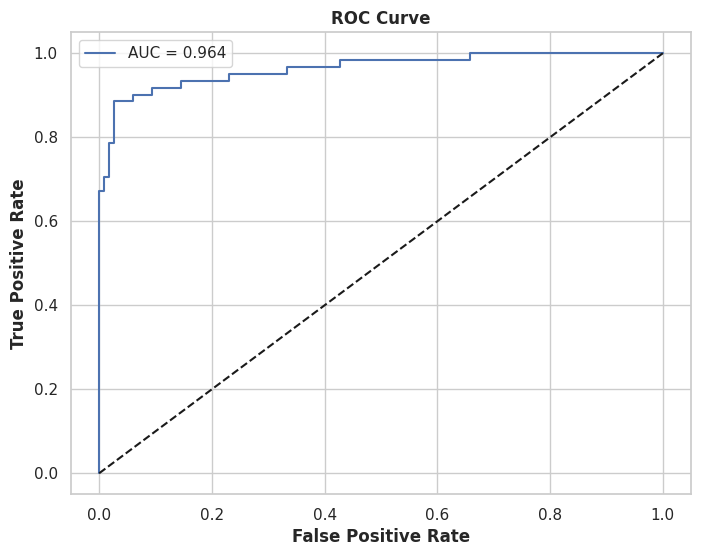

In [60]:


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.savefig("ProtBERT_test_ROC_curve.tiff", dpi=600, format="tiff")
plt.show()
plt.close()

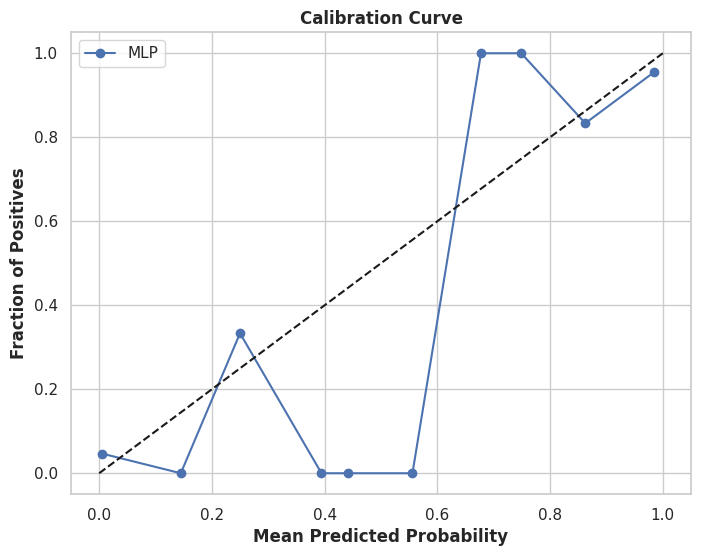

In [61]:

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='MLP')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)

plt.savefig("ProtBERT_test_calibration_curve.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


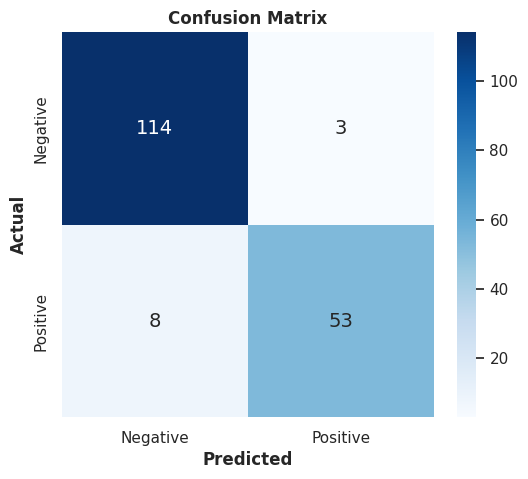

In [62]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig("ProtBERT_test_confusion_matrix.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


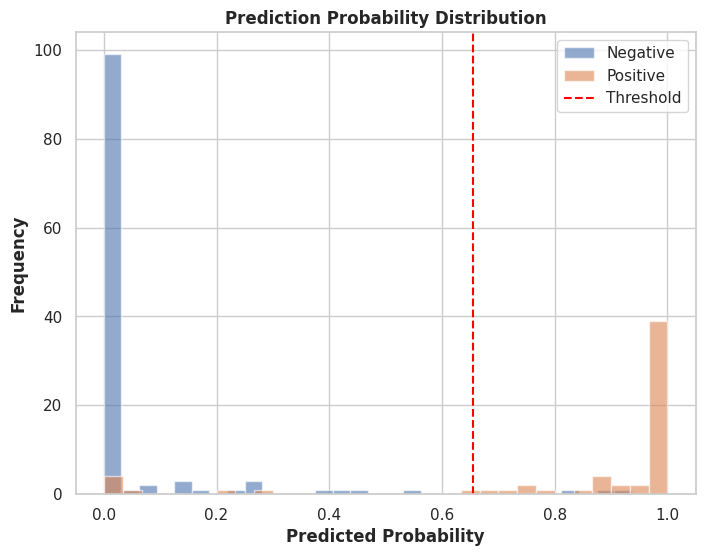

In [63]:

plt.figure(figsize=(8, 6))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Negative')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Positive')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution')
plt.legend()

plt.savefig("ProtBERT_test_probability_distribution.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


In [64]:


metrics_dict = {
    "Metric": [
        "Accuracy",
        "Specificity",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC",
        "AUC",
        "Brier Score"
    ],
    "Value": [
        accuracy,
        specificity,
        precision,
        sensitivity,
        f1,
        mcc,
        auc,
        brier
    ]
}

metrics_df = pd.DataFrame(metrics_dict)

metrics_df.to_csv("ProtBERT_test_metrics.csv", index=False)
print(metrics_df)
print("\nMetrics saved to ProtBERT_test_metrics.csv")

        Metric     Value
0     Accuracy  0.938202
1  Specificity  0.974359
2    Precision  0.946429
3       Recall  0.868852
4     F1 Score  0.905983
5          MCC  0.861828
6          AUC  0.963850
7  Brier Score  0.056971

Metrics saved to ProtBERT_test_metrics.csv


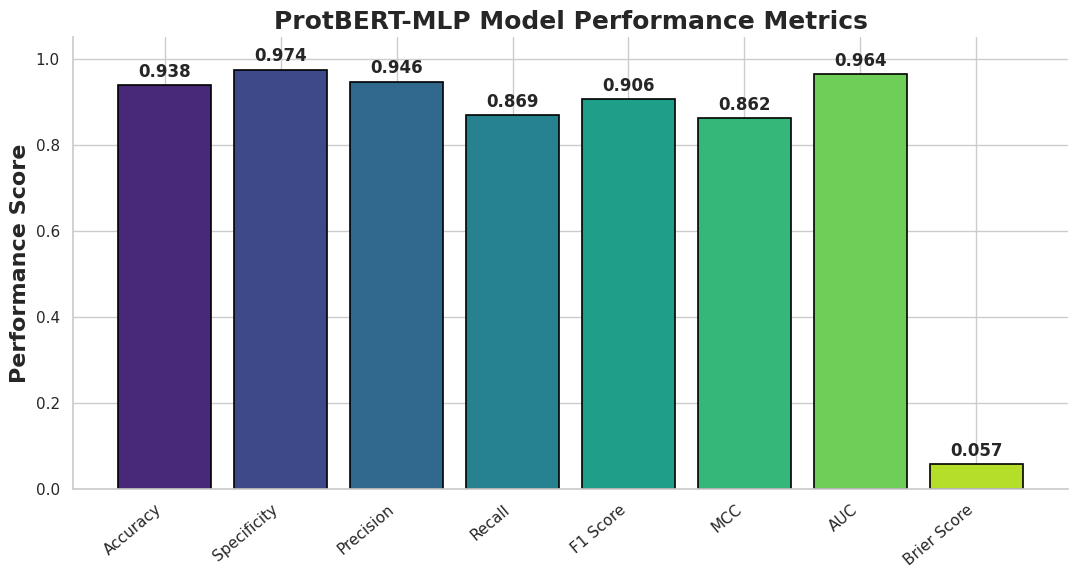

Colorful bar plot saved as ProtBERT_test_metrics_colorful_barplot.tiff


In [65]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set elegant theme
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# Custom vibrant but professional color palette
colors = sns.color_palette("viridis", len(metrics_df))

plt.figure(figsize=(11, 6))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

plt.ylim(0, 1.05)
plt.xticks(rotation=40, ha='right')
plt.ylabel("Performance Score", fontsize=16)
plt.title("ProtBERT-MLP Model Performance Metrics", fontsize=18, weight='bold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha='center',
        fontsize=12,
        weight='bold'
    )

# Remove top/right borders
sns.despine()

plt.tight_layout()

plt.savefig("ProtBERT_test_metrics_colorful_barplot.tiff",
            dpi=600,
            format="tiff")

plt.show()

print("Colorful bar plot saved as ProtBERT_test_metrics_colorful_barplot.tiff")

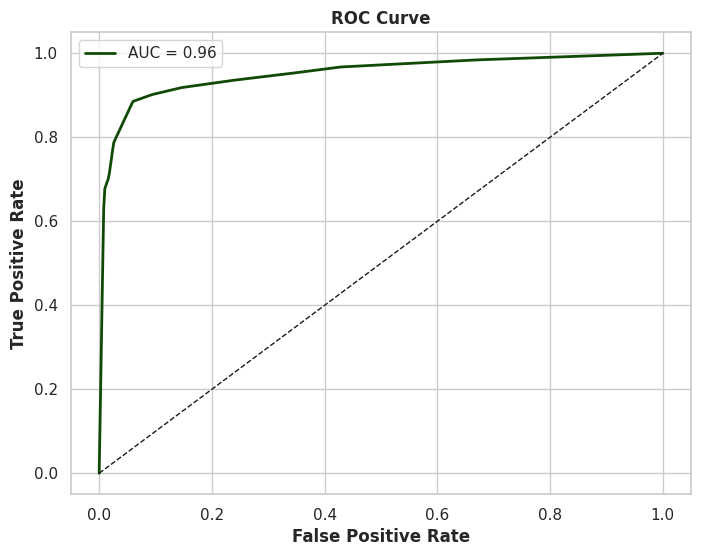

In [66]:

import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Remove duplicate FPR values (important for smoothing)
fpr_unique, idx = np.unique(fpr, return_index=True)
tpr_unique = tpr[idx]

# Create smooth grid
fpr_smooth = np.linspace(0, 1, 500)
tpr_smooth = np.interp(fpr_smooth, fpr_unique, tpr_unique)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_smooth, tpr_smooth,
         linewidth=2,
         color="#114A07",
         label=f'AUC = {auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("ProtBERT_test_ROC_curve_smoothen.tiff", dpi=600, format="tiff")
plt.show()
plt.close()